In [34]:
#import block
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from hmmlearn import hmm

In [35]:
#data load block

features_df = pd.read_csv('UCI HAR Dataset/features.txt', sep='\\s+', header=None, names=['column_index', 'feature_name'])
column_names = features_df['feature_name'].tolist()
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\\s+', header=None)
X_train.columns = column_names
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', header=None, names=['activity_label'])



Definimos las observaciones con los índices:

$$I_{acc} = \frac{tBodyAccMag\text{-}mean() + tBodyAccMag\text{-}std()}{2}$$
$$I_{gyro} = \frac{tBodyGyroMag\text{-}mean() + tBodyGyroMag\text{-}std()}{2}$$

In [36]:
I_acc = (X_train['tBodyAccMag-mean()'] + X_train['tBodyAccMag-std()']) / 2
I_gyro = (X_train['tBodyGyroMag-mean()'] + X_train['tBodyGyroMag-std()']) / 2

Y para determinar qué tipo de discretización usar, realizamos un histograma para observar la distribución de los datos:

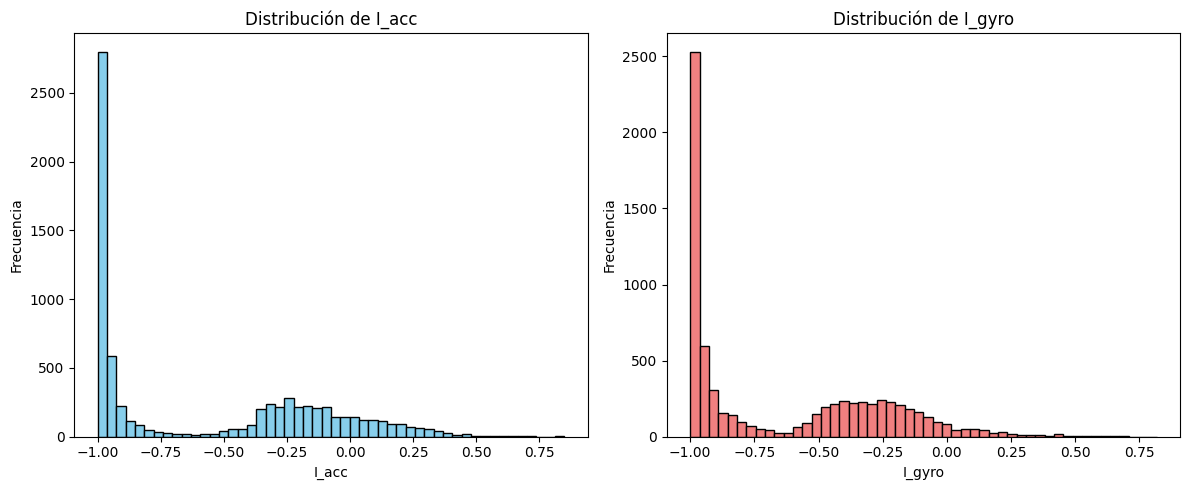

In [37]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(I_acc, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de I_acc')
plt.xlabel('I_acc')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(I_gyro, bins=50, color='lightcoral', edgecolor='black')
plt.title('Distribución de I_gyro')
plt.xlabel('I_gyro')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Se puede observar en ambos dos áreas principales: una frecuencia muy alta al inicio, seguido de una drástica baja, y una agrupación de frecuencias entre -0.5 y 0.25. Esto representa una **distribución multimodal**, por lo que una buena forma de discretizar es utilizando agrupación *K-medias/K-means*.